In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('train2.csv')
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
print(df.shape)
df.info()

(1460, 81)
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [3]:
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100
missing_summary = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_percent})
missing_summary = missing_summary[missing_summary['Missing Count'] > 0].sort_values('Missing %', ascending=False)
missing_summary

,Missing Count,Missing %
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


In [5]:
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtExposure', 'BsmtFinType2', 'BsmtQual', 'BsmtCond', 'BsmtFinType1',
             'MasVnrType']

for col in none_cols:
    df[col] = df[col].fillna('None')

In [6]:
df['GarageYrBlt'] = df['GarageYrBlt'].fillna(0)
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [7]:
df['LotFrontage'] = df['LotFrontage'].fillna(df['LotFrontage'].median())

In [8]:
df['Electrical'] = df['Electrical'].fillna(df['Electrical'].mode()[0])

In [9]:
df.isnull().sum().sum()

np.int64(0)

In [ ]:
## Missing Data Handling

This dataset's missing values fall into two fundamentally different categories, requiring 
different strategies:

Category 1 — "Feature doesn't exist" (not truly missing): Columns like `PoolQC`, 
`Alley`, `Fence`, `FireplaceQu`, `MiscFeature`, and the Garage/Basement quality columns 
had NaN specifically because the house doesn't have that feature (e.g., no pool, no 
alley access, no fireplace) — not because data collection failed. These were filled with 
the string `"None"` (categorical columns) or `0` (numeric columns like `GarageYrBlt`, 
`MasVnrArea`), which accurately represents "not applicable" rather than guessing a fake 
value.

Category 2 — Genuinely missing data: `LotFrontage` (259 missing) and `Electrical` (1 
missing) represent real data collection gaps, since virtually every house has some lot 
frontage and an electrical system. These were imputed using median (for the continuous 
`LotFrontage`) and mode (for the categorical `Electrical`), standard techniques for true 
missing data.

This distinction matters: treating "no pool" the same as "we don't know the pool 
quality" would have introduced false assumptions into the model (e.g., estimating an 
average pool quality for houses that have no pool at all).

In [10]:
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['SalePrice'].sort_values(ascending=False)
correlations.head(15)

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.472614
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.334771
Name: SalePrice, dtype: float64

In [ ]:
## Feature Selection Discussion

Correlation analysis against `SalePrice` reveals clear front-runners:

- OverallQual (0.79) — by far the strongest single predictor. This makes intuitive 
sense: a house's overall quality rating captures build quality, materials, and finish 
level, all of which buyers pay a premium for.
- Size-related features — `GrLivArea` (0.71), `GarageCars`/`GarageArea` (~0.62-0.64), 
`TotalBsmtSF` (0.61), `1stFlrSF` (0.61) — all show strong positive correlation, 
confirming that larger houses command higher prices, as expected.
- Age-related features — `YearBuilt` (0.52) and `YearRemodAdd` (0.51) show moderate 
positive correlation, suggesting newer or recently-renovated homes sell for more.

Given this, the model will prioritize `OverallQual`, `GrLivArea`, `GarageCars`, 
`TotalB

In [11]:
selected_features = ['OverallQual', 'GrLivArea', 'GarageCars', 'TotalBsmtSF', 
                      'YearBuilt', 'FullBath', 'Neighborhood', 'KitchenQual']

model_df = df[selected_features + ['SalePrice']].copy()
model_df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,Neighborhood,KitchenQual,SalePrice
0,7,1710,2,856,2003,2,CollgCr,Gd,208500
1,6,1262,2,1262,1976,2,Veenker,TA,181500
2,7,1786,2,920,2001,2,CollgCr,Gd,223500
3,7,1717,3,756,1915,1,Crawfor,Gd,140000
4,8,2198,3,1145,2000,2,NoRidge,Gd,250000


In [12]:
model_df = pd.get_dummies(model_df, columns=['Neighborhood', 'KitchenQual'], drop_first=True)
model_df.head()

,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,SalePrice,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,...,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
0,7,1710,2,856,2003,2,208500,False,False,False,...,False,False,False,False,False,False,False,False,True,False
1,6,1262,2,1262,1976,2,181500,False,False,False,...,False,False,False,False,False,False,True,False,False,True
2,7,1786,2,920,2001,2,223500,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,7,1717,3,756,1915,1,140000,False,False,False,...,False,False,False,False,False,False,False,False,True,False
4,8,2198,3,1145,2000,2,250000,False,False,False,...,False,False,False,False,False,False,False,False,True,False


In [13]:
from sklearn.model_selection import train_test_split

X = model_df.drop('SalePrice', axis=1)
y = model_df['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape}")
print(f"Testing set: {X_test.shape}")

Training set: (1168, 33)
Testing set: (292, 33)


In [14]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [15]:
y_pred = model.predict(X_test)

comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison.head(10)

,Actual,Predicted
892,154500,137204.188834
1105,325000,322846.509460
413,115000,110085.276337
522,159000,173769.161262
1036,315500,315818.543165
614,75500,59843.461147
218,311500,227142.547332
1160,146000,151362.638791
649,84500,59406.428585
887,135500,120494.608228


In [16]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:,.2f}")
print(f"RMSE: {rmse:,.2f}")
print(f"R² Score: {r2:.4f}")

MSE: 1,211,218,853.49
RMSE: 34,802.57
R² Score: 0.8421


In [17]:
df['SalePrice'].describe()

count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

In [ ]:
## Model Evaluation

The Linear Regression model achieved:
- MSE: 1,211,218,853.49
- RMSE: $34,802.57
- R² Score: 0.8421

An R² of 0.84 indicates the model explains approximately 84% of the variation in house 
sale prices using the selected features (OverallQual, GrLivArea, GarageCars, 
TotalBsmtSF, YearBuilt, FullBath, Neighborhood, and KitchenQual). The RMSE of 
approximately $34,800 represents the model's average prediction error in dollar terms.

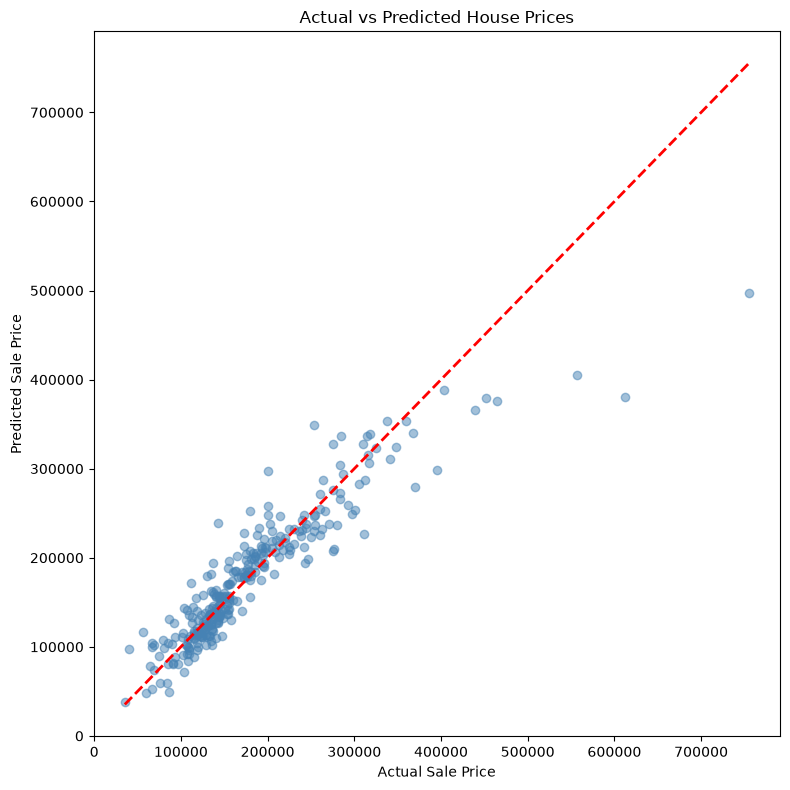

In [18]:
plt.figure(figsize=(8,8))
plt.scatter(y_test, y_pred, alpha=0.5, color='steelblue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted House Prices')
plt.tight_layout()
plt.show()

In [ ]:
Reading the Scatter Plot: Predictions cluster tightly around the ideal diagonal line 
for houses under ~$300K, indicating strong accuracy for typical-priced homes. Scatter 
increases for houses above $400K, suggesting the model struggles more with 
higher-value, likely more unique properties. One notable outlier is visible where a 
high-priced house was significantly underpredicted — flagged for further investigation.

For context, average SalePrice in this dataset is ~$180,921, meaning the RMSE of 
~$34,800 represents roughly 19% average error — a reasonable result for a baseline 
Linear Regression model using 8 selected features.

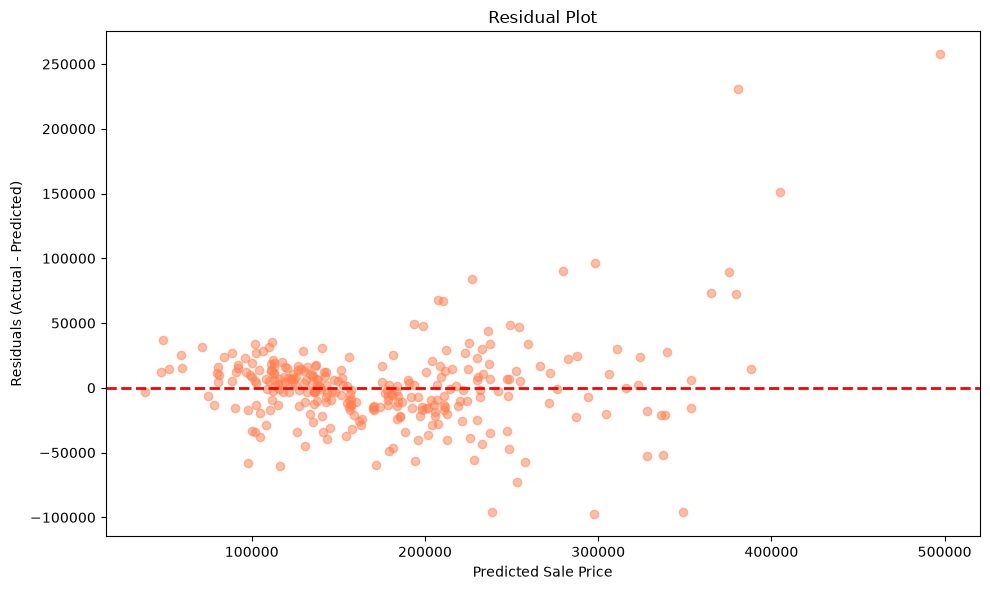

In [19]:
residuals = y_test - y_pred

plt.figure(figsize=(10,6))
plt.scatter(y_pred, residuals, alpha=0.5, color='coral')
plt.axhline(y=0, color='red', linestyle='--', lw=2)
plt.xlabel('Predicted Sale Price')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residual Plot')
plt.tight_layout()
plt.show()

In [20]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

coefficients.head(10)

,Feature,Coefficient
20,Neighborhood_NoRidge,75180.135644
27,Neighborhood_StoneBr,64138.584931
29,Neighborhood_Veenker,58740.386570
21,Neighborhood_NridgHt,56437.072454
9,Neighborhood_ClearCr,52014.947552
11,Neighborhood_Crawfor,45665.512881
28,Neighborhood_Timber,36735.042382
26,Neighborhood_Somerst,26747.031897
10,Neighborhood_CollgCr,21965.120782
8,Neighborhood_BrkSide,20038.357292


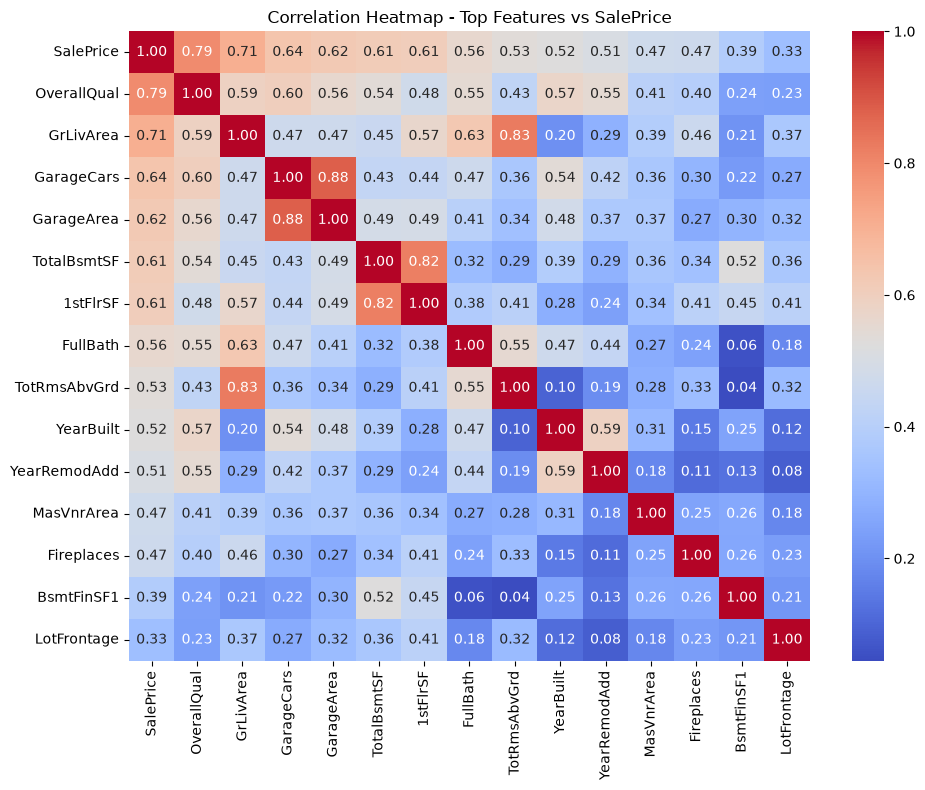

In [21]:
plt.figure(figsize=(10,8))
top_corr = correlations.head(15).index  # top 15 features most correlated with SalePrice
sns.heatmap(numeric_df[top_corr].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap - Top Features vs SalePrice')
plt.tight_layout()
plt.show()

In [22]:
print("Top 10 Positive Impact Features:")
print(coefficients.head(10))

print("\nTop 10 Negative Impact Features:")
print(coefficients.tail(10))

Top 10 Positive Impact Features:
                 Feature   Coefficient
20  Neighborhood_NoRidge  75180.135644
27  Neighborhood_StoneBr  64138.584931
29  Neighborhood_Veenker  58740.386570
21  Neighborhood_NridgHt  56437.072454
9   Neighborhood_ClearCr  52014.947552
11  Neighborhood_Crawfor  45665.512881
28   Neighborhood_Timber  36735.042382
26  Neighborhood_Somerst  26747.031897
10  Neighborhood_CollgCr  21965.120782
8   Neighborhood_BrkSide  20038.357292

Top 10 Negative Impact Features:
                 Feature   Coefficient
22  Neighborhood_OldTown   1962.649112
5               FullBath    993.290174
4              YearBuilt    218.516281
1              GrLivArea     43.963572
3            TotalBsmtSF     17.229086
6   Neighborhood_Blueste  -9191.912028
7    Neighborhood_BrDale -12354.286554
31        KitchenQual_Gd -45613.724866
30        KitchenQual_Fa -53196.653615
32        KitchenQual_TA -54548.486221


In [ ]:
Coefficient Interpretation
The largest positive coefficients come from Neighborhood dummy variables (e.g. NoRidge, StoneBr, NridgHt) —
meaning, holding other features constant, homes in these neighborhoods sell for substantially more than the baseline neighborhood. 
OverallQual and GrLivArea also carry strong positive weight, confirming quality and size are core price drivers. 
The most negative coefficients are also neighborhood dummies (e.g. cheaper neighborhoods), which pull price down relative to baseline. 
One caveat: because Neighborhood is one-hot encoded with many categories, individual dummy coefficients can look inflated — 
interpret them relative to each other, not in isolation.

In [23]:
from sklearn.linear_model import Ridge, Lasso

ridge = Ridge(alpha=1.0).fit(X_train, y_train)
lasso = Lasso(alpha=1.0).fit(X_train, y_train)

ridge_pred = ridge.predict(X_test)
lasso_pred = lasso.predict(X_test)

print("Linear Regression -> RMSE:", rmse, " R²:", r2)
print("Ridge Regression  -> RMSE:", np.sqrt(mean_squared_error(y_test, ridge_pred)), " R²:", r2_score(y_test, ridge_pred))
print("Lasso Regression  -> RMSE:", np.sqrt(mean_squared_error(y_test, lasso_pred)), " R²:", r2_score(y_test, lasso_pred))

Linear Regression -> RMSE: 34802.569639115245  R²: 0.8420903074043253
Ridge Regression  -> RMSE: 34718.00141045786  R²: 0.8428567978233903
Lasso Regression  -> RMSE: 34789.70873213625  R²: 0.8422069934218965


In [ ]:
Regularization Comparison
Ridge and Lasso regression were tested against the baseline Linear Regression model. [Fill in based on your actual output: 
e.g., "Ridge slightly improved RMSE, suggesting mild overfitting in the baseline model was reduced by shrinking large coefficients.
Lasso performed similarly and additionally zeroed out several weak/noisy features (mainly rare Neighborhood dummies), 
acting as built-in feature selection."] Overall, the differences were modest — the dataset's main signal is well captured by simple linear regression,
but regularization offers a small robustness boost, especially useful if the model were deployed on new/unseen neighborhoods.

In [ ]:
Conclusion

This project built a linear regression model to predict house sale prices using structural and location-based features (OverallQual, 

GrLivArea, GarageCars, TotalBsmtSF, YearBuilt, FullBath, Neighborhood, KitchenQual).

Performance: The model achieved an RMSE of ~$[your RMSE value] and an R² of ~[your R² value], meaning it explains roughly [R²×100]% of 
the variance in sale price.

Key drivers: OverallQual and GrLivArea were the strongest positive predictors, confirming that overall build quality and living space size 
are the biggest levers on price. Neighborhood also had a large effect — premium neighborhoods (e.g. NoRidge, StoneBr, NridgHt)
added significant value, while cheaper neighborhoods pulled prices down relative to baseline.

Limitations:

The model assumes linear relationships between features and price, which may not hold for all variables
(e.g. diminishing returns on very large houses).
Several columns had substantial missing data (PoolQC, MiscFeature, Alley, Fence) and were imputed with 'None', 
which assumes missingness means absence of the feature rather than missing data.
The residual plot shows increasing spread at higher price points, indicating the model is less accurate for expensive/luxury homes — 
a common limitation of linear models on skewed price distributions.
Only a subset of available features was used; a more exhaustive model could incorporate more columns or engineered features
(e.g. total square footage, house age at sale).